<a href="https://colab.research.google.com/github/qianzhiqiang03-tech/Statistics/blob/main/Week%203/BDAO_Block5_NLP_Notebook_Student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BDAO Block 5 — Practical NLP
### British Airways Reviews · Sentiment · Topic Modelling · Short-form Text

**Before you start:** Go to `Runtime → Change runtime type → T4 GPU` and save.
This reduces model runtime from minutes to seconds.

| Part | Technique | Text | Business question |
|---|---|---|---|
| 1 | Sentiment analysis | Reviews | Are customers positive or negative — and does the star rating tell the full story? |
| 2 | BERTopic | Reviews | What themes are customers actually talking about? |
| 3 | KeyBERT + Zero-shot | Titles | What can short-form text tell us? |
| 4 | Synthesis | All | Which technique for which business question? |

---
### One important point before we start

Traditional NLP cleaning — removing stopwords, stemming, lowercasing — **hurts transformer-based models**. Transformers were pre-trained on natural text including punctuation, capitalisation and common words. Stripping these away removes the context the model depends on.

For modern NLP, cleaning means: remove duplicates, filter very short texts, handle encoding errors. That is all. Do not lemmatise. Do not remove stopwords.

---
## Step 1 — Install libraries and check GPU

In [5]:
# Install all libraries
# Run this cell first — takes 2-3 minutes
!pip install transformers torch bertopic sentence-transformers \
            keybert umap-learn hdbscan plotly vaderSentiment --quiet
print('Installation complete.')

Installation complete.


In [6]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import re

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 120)
plt.style.use('seaborn-v0_8-whitegrid')

# Check GPU availability
# If this shows 'cuda' you have a T4 GPU — models will run much faster
# If this shows 'cpu' go to Runtime → Change runtime type → T4 GPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')
if device == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('No GPU detected. Models will run on CPU — slower but still works.')
    print('Go to Runtime → Change runtime type → T4 GPU for faster performance.')

Device: cuda
GPU: Tesla T4
GPU memory: 15.6 GB


---
## Step 2 — Load and prepare the data

Upload `british_airways_reviews.csv` using the file panel on the left (📁 icon),
or run the cell below to mount Google Drive if you have saved it there.

In [7]:
# Upload directly (click the folder icon on the left → upload)
df = pd.read_csv('/content/british_airways_reviews.csv')
df.head()

,title,reviews,published_dates,user_name,user_location,user_ratings,trip_details,would_recommed_to_others
0,“Worst service ever”,Worst service ever. Lost baggage because of delayed flight and missed connection and no one is helping to get it ba...,23rd January 2024,Chirag Thummar,Germany,1,Type Of TravellerSolo Leisure\nSeat TypeEconomy Class\nRouteBoston to Düsseldorf via London\nDate FlownJanuary 2024,n
1,"""unprofessional attitude of the pilots""",BA 246 21JAN 2023 Did not appreciate the unprofessional attitude of the pilots. Flight scheduled departure 16:20. ...,21st January 2024,D Carreno,United Kingdom,6,AircraftA350\nType Of TravellerBusiness\nSeat TypeEconomy Class\nRouteSao Paulo to London Heathrow\nDate FlownJanuar...,n
2,“Next time it will be Jet2”,Not a great experience. I could not check in online as two separate parts of the BA computer system do not talk to ...,18th January 2024,Simon Channon,United Kingdom,3,AircraftA320\nType Of TravellerCouple Leisure\nSeat TypeEconomy Class\nRouteLondon Heathrow to Lisbon\nDate FlownJan...,n
3,“become the Ryanair of long-haul travel”,I was excited to fly BA as I'd not travelled with them long haul for over 25yrs. I've travelled to Australia on man...,18th January 2024,Melissa Harris,United Kingdom,2,Type Of TravellerFamily Leisure\nSeat TypeEconomy Class\nRouteLondon to Hong Kong \nDate FlownJanuary 2024,n
4,“They never help us”,I just want to warn everyone of the worst customer service experience ever! It really looks like British Airways c...,17th January 2024,Ivana Squassabia,Germany,1,Type Of TravellerFamily Leisure\nSeat TypeBusiness Class\nRouteDusseldorf (DUS) to Miami (MIA) \nDate FlownJanuary 2024,n


In [8]:
# Validate and understand data
print('=== 1. SHAPE ===')
print(df.shape)
print()
print('=== 2. DATA TYPES ===')
print(df.dtypes)
print()
print('=== 3. MISSING VALUES ===')
print(df.isnull().sum())
print()
print('=== 4. DUPLICATES ===')
print(df.duplicated().sum())
print()
print('=== 5. UNIQUE VALUES ===')
for col in df.columns:
    n = df[col].nunique()
    print(f'  {col}: {n} unique')

=== 1. SHAPE ===
(1300, 8)

=== 2. DATA TYPES ===
title                       object
reviews                     object
published_dates             object
user_name                   object
user_location               object
user_ratings                 int64
trip_details                object
would_recommed_to_others    object
dtype: object

=== 3. MISSING VALUES ===
title                       0
reviews                     0
published_dates             0
user_name                   0
user_location               0
user_ratings                0
trip_details                0
would_recommed_to_others    0
dtype: int64

=== 4. DUPLICATES ===
0

=== 5. UNIQUE VALUES ===
  title: 1278 unique
  reviews: 1300 unique
  published_dates: 901 unique
  user_name: 1112 unique
  user_location: 57 unique
  user_ratings: 10 unique
  trip_details: 1297 unique
  would_recommed_to_others: 2 unique


In [9]:
# Fix the data type - published_dates, would_recommend_to_others
df['published_dates'] = pd.to_datetime(df['published_dates'],format='mixed')
df['would_recommed_to_others'] = df['would_recommed_to_others'].apply(lambda x: False if x=="n" else True)
print(df.dtypes)

title                               object
reviews                             object
published_dates             datetime64[ns]
user_name                           object
user_location                       object
user_ratings                         int64
trip_details                        object
would_recommed_to_others              bool
dtype: object


From the first eye-check of data, we found that column `trip_details` contains lots of travelling information which could be useful. For example:


> Type Of TravellerSolo Leisure\nSeat TypeEconomy Class\nRouteBoston to Düsseldorf via London\nDate FlownJanuary 2024


We can parse the information into new columns, but we need to understand the structure. Here we can see seat type follows "Seat Type", traveller type follows "Type of Traveller", route follows "Route" and date flown follows "Date Flown" and all of them are split with newline character \n. So we can just search this keyword and take the chartacters until seeing the newline character.




In [10]:
details_str = df['trip_details'][0]
seat_match = re.search(r'Seat Type([^\n]+)', details_str)
seat_match.group()

'Seat TypeEconomy Class'

In [11]:
def parse_trip_details(details):
    result = {'seat_type': None, 'traveller_type': None, 'route': None, 'date_flown': None}
    if pd.isna(details):
        return result

    details_str = str(details)

    # Extract Seat Type
    seat_match = re.search(r'Seat Type([^\n]+)', details_str)
    # This means Find the literal text 'Seat Type', and then capture one or more characters that are not a newline character immediately following it."
    # This effectively extracts the text after "Seat Type" up until the next line break.
    # Same approach applied to finding traveller type, route and date flown
    if seat_match:
        result['seat_type'] = seat_match.group(1).strip()

    # Extract Type Of Traveller
    traveller_match = re.search(r'Type Of Traveller([^\n]+)', details_str)
    if traveller_match:
        result['traveller_type'] = traveller_match.group(1).strip()

    # Extract Route
    route_match = re.search(r'Route([^\n]+)', details_str)
    if route_match:
        result['route'] = route_match.group(1).strip()

    # Extract Date Flown
    date_flown_match = re.search(r'Date Flown([^\n]+)', details_str)
    if date_flown_match:
        result['date_flown'] = date_flown_match.group(1).strip()

    return result

# Apply the function and create new columns
trip_parsed = df['trip_details'].apply(parse_trip_details).apply(pd.Series)

# Concatenate with the original DataFrame
df = pd.concat([df, trip_parsed], axis=1)

# Display the head of the DataFrame with new columns
print('DataFrame head with extracted trip details:')
df[['trip_details', 'seat_type', 'traveller_type', 'route', 'date_flown']].head()

DataFrame head with extracted trip details:


,trip_details,seat_type,traveller_type,route,date_flown
0,Type Of TravellerSolo Leisure\nSeat TypeEconomy Class\nRouteBoston to Düsseldorf via London\nDate FlownJanuary 2024,Economy Class,Solo Leisure,Boston to Düsseldorf via London,January 2024
1,AircraftA350\nType Of TravellerBusiness\nSeat TypeEconomy Class\nRouteSao Paulo to London Heathrow\nDate FlownJanuar...,Economy Class,Business,Sao Paulo to London Heathrow,January 2024
2,AircraftA320\nType Of TravellerCouple Leisure\nSeat TypeEconomy Class\nRouteLondon Heathrow to Lisbon\nDate FlownJan...,Economy Class,Couple Leisure,London Heathrow to Lisbon,January 2024
3,Type Of TravellerFamily Leisure\nSeat TypeEconomy Class\nRouteLondon to Hong Kong \nDate FlownJanuary 2024,Economy Class,Family Leisure,London to Hong Kong,January 2024
4,Type Of TravellerFamily Leisure\nSeat TypeBusiness Class\nRouteDusseldorf (DUS) to Miami (MIA) \nDate FlownJanuary 2024,Business Class,Family Leisure,Dusseldorf (DUS) to Miami (MIA),January 2024


In [12]:
# Titles now with quotation marks, so we will remove them, either " or '
df['title'] = df['title'].astype(str).str.strip()
df['title'] = df['title'].str.replace('“', '').str.replace('”', '').str.replace('"', '').str.replace("'", '')

In [13]:
# The length of text impacts the model results and some models might perform badly because of text being too short
# Thus, we are creating a new column "word_count" to better understand the text length before running any model and we can filter out short text later when building models
df['word_count'] = df['reviews'].str.split().str.len()

In [14]:
# Because we will mainly do sentiment analysis and topic modelling with transformer for word embedding, we do not need traditional text cleanning process
# Some traditional cleaning steps such as lowercasing or removing punctuation might hurt the performance of the models
# Thus, we are including a basic text cleanning here to remove encoding noise
# Specifically, we are removing email, urls, extra white spaces and newline characters

import re

def clean_for_nlp(text):
    text = str(text)
    text = re.sub('http://\S+|https://\S+', '', text)      # remove URLs
    text = re.sub(r'\S+@\S+\.\S+', '', text)           # remove email addresses
    text = re.sub(r'[\r\n\t]+', ' ', text)             # replace newlines/tabs with space
    text = re.sub(r' {2,}', ' ', text)                 # collapse multiple spaces
    return text.strip()

# Return two new columns with cleaned text which we will use for modelling
df['reviews_clean'] = df['reviews'].apply(clean_for_nlp)
df['title_clean']   = df['title'].apply(clean_for_nlp)

In [15]:
# Now check the final data after processing
print(f'Loaded: {len(df):,} reviews')
print(f'Date range: {df["published_dates"].iloc[-1]} to {df["published_dates"].iloc[0]}')
print(f'Avg review length: {df["word_count"].mean():.0f} words')
print()
df.head()

Loaded: 1,300 reviews
Date range: 2018-03-28 00:00:00 to 2024-01-23 00:00:00
Avg review length: 150 words



,title,reviews,published_dates,user_name,user_location,user_ratings,trip_details,would_recommed_to_others,seat_type,traveller_type,route,date_flown,word_count,reviews_clean,title_clean
0,Worst service ever,Worst service ever. Lost baggage because of delayed flight and missed connection and no one is helping to get it ba...,2024-01-23,Chirag Thummar,Germany,1,Type Of TravellerSolo Leisure\nSeat TypeEconomy Class\nRouteBoston to Düsseldorf via London\nDate FlownJanuary 2024,False,Economy Class,Solo Leisure,Boston to Düsseldorf via London,January 2024,57,Worst service ever. Lost baggage because of delayed flight and missed connection and no one is helping to get it bac...,Worst service ever
1,unprofessional attitude of the pilots,BA 246 21JAN 2023 Did not appreciate the unprofessional attitude of the pilots. Flight scheduled departure 16:20. ...,2024-01-21,D Carreno,United Kingdom,6,AircraftA350\nType Of TravellerBusiness\nSeat TypeEconomy Class\nRouteSao Paulo to London Heathrow\nDate FlownJanuar...,False,Economy Class,Business,Sao Paulo to London Heathrow,January 2024,124,BA 246 21JAN 2023 Did not appreciate the unprofessional attitude of the pilots. Flight scheduled departure 16:20. Ad...,unprofessional attitude of the pilots
2,Next time it will be Jet2,Not a great experience. I could not check in online as two separate parts of the BA computer system do not talk to ...,2024-01-18,Simon Channon,United Kingdom,3,AircraftA320\nType Of TravellerCouple Leisure\nSeat TypeEconomy Class\nRouteLondon Heathrow to Lisbon\nDate FlownJan...,False,Economy Class,Couple Leisure,London Heathrow to Lisbon,January 2024,123,Not a great experience. I could not check in online as two separate parts of the BA computer system do not talk to e...,Next time it will be Jet2
3,become the Ryanair of long-haul travel,I was excited to fly BA as I'd not travelled with them long haul for over 25yrs. I've travelled to Australia on man...,2024-01-18,Melissa Harris,United Kingdom,2,Type Of TravellerFamily Leisure\nSeat TypeEconomy Class\nRouteLondon to Hong Kong \nDate FlownJanuary 2024,False,Economy Class,Family Leisure,London to Hong Kong,January 2024,222,I was excited to fly BA as I'd not travelled with them long haul for over 25yrs. I've travelled to Australia on many...,become the Ryanair of long-haul travel
4,They never help us,I just want to warn everyone of the worst customer service experience ever! It really looks like British Airways c...,2024-01-17,Ivana Squassabia,Germany,1,Type Of TravellerFamily Leisure\nSeat TypeBusiness Class\nRouteDusseldorf (DUS) to Miami (MIA) \nDate FlownJanuary 2024,False,Business Class,Family Leisure,Dusseldorf (DUS) to Miami (MIA),January 2024,448,I just want to warn everyone of the worst customer service experience ever! It really looks like British Airways cus...,They never help us


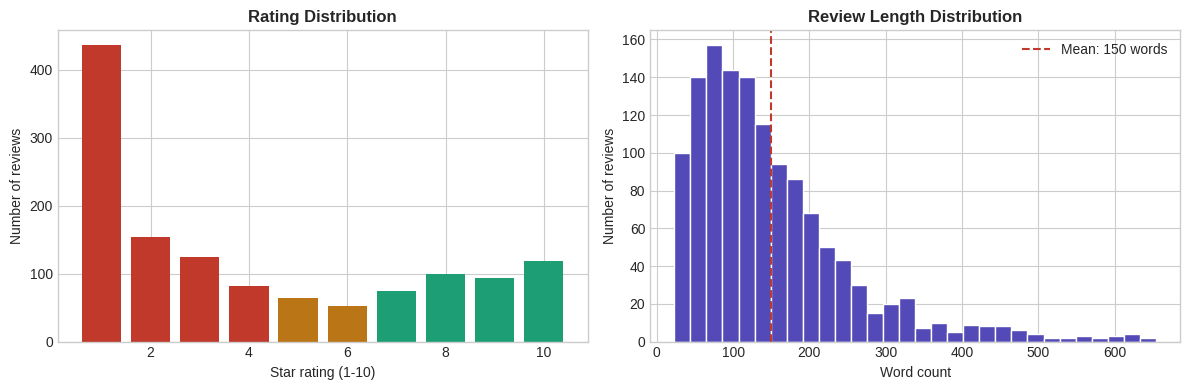

Would recommend: {False: 867, True: 433}


In [16]:
# Overview of rating and review length
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Rating distribution
rating_counts = df['user_ratings'].value_counts().sort_index()
colors = ['#C0392B' if r <= 4 else '#BA7517' if r <= 6 else '#1D9E75'
          for r in rating_counts.index]
axes[0].bar(rating_counts.index, rating_counts.values, color=colors)
axes[0].set_title('Rating Distribution', fontweight='bold')
axes[0].set_xlabel('Star rating (1-10)')
axes[0].set_ylabel('Number of reviews')

# Review length distribution
axes[1].hist(df['word_count'], bins=30, color='#534AB7', edgecolor='white')
axes[1].axvline(df['word_count'].mean(), color='#C0392B',
                linestyle='--', label=f'Mean: {df["word_count"].mean():.0f} words')
axes[1].set_title('Review Length Distribution', fontweight='bold')
axes[1].set_xlabel('Word count')
axes[1].set_ylabel('Number of reviews')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Would recommend: {df["would_recommed_to_others"].value_counts().to_dict()}')

From the above visualisation, we can see this is a heavily negative dataset, which might reflect lots of issues with British Airway. The overall review length looks good, but there are some short reviews with word count lower than 50 which might need some attentions.

---
## Part 1 — Sentiment Analysis

**Business question:** Are customers positive or negative overall — and does the star rating accurately reflect what they say in the text?

We compare two approaches:

| Approach | Method | Speed | Strength |
|---|---|---|---|
| **VADER** | Rule-based, keyword scoring | Instant | Good baseline, works without GPU |
| **nlptown BERT** | Transformer, trained on reviews | Fast with GPU | Predicts 1-5 stars from text — directly comparable to actual ratings |

### 1.1 — VADER (rule-based baseline)

**Vader Sentiment analysis** is a trational approach for doing sentiment analysis, and VADER means Valence Aware Dictionary and Sentiment Reasoner.Vader is a lexicon and rule-based feeling analysis instrument that is explicitly sensitive to suppositions communicated in web-based media. Vader utilizes a mix of lexical highlights (e.g., words) that are, for the most part, marked by their semantic direction as positive or negative or neutral. Thus, Vader not only tells about the Polarity score yet, in addition, it tells us concerning how positive or negative a text is. What we are going to use the the vader analysis package from **NLTK** (which is a very famous library for NLP and you will see it a lot when we are doing other text mining tasks). By running the analysis using this package, you will get 4 polarity scores, namely compound, neg(ative), pos(itive), neu(tral). About the scoring, please check: https://github.com/cjhutto/vaderSentiment#about-the-scoring. Usually we use +-0.05 as benchmark to classify the sentence as positive or negative or neutral.

In [17]:
# first, import the package (suppose we haven't imported it yet) run the analyzer (SentimentIntensityAnalyzer())
import nltk
import numpy as np
nltk.download('vader_lexicon')
from nltk.sentiment.vader import SentimentIntensityAnalyzer
sid = SentimentIntensityAnalyzer()

# Then create new columns for your dataframe (compound, pos, neu, neg) with empty dictionary
# With for loop, we get the scores for each review and append the scores to the dictionary

target_column = 'reviews_clean' # Change it to the text column you would like to analyse

Result = { 'compound':[], 'pos':[] , 'neu':[], 'neg':[] }

for review in df[target_column]:
    score = sid.polarity_scores(review)
    Result['pos'].append(score['pos'])
    Result['neu'].append(score['neu'])
    Result['neg'].append(score['neg'])
    Result['compound'].append(score['compound'])

# Once this is done, new columns are created and dictionary is transformed to the dataframe

df['compound'] = pd.DataFrame(Result)['compound']
df['pos'] = pd.DataFrame(Result)['pos']
df['neu'] = pd.DataFrame(Result)['neu']
df['neg'] = pd.DataFrame(Result)['neg']
df['vader_sentiment'] = np.where(df['compound']>=0.05, 'Positive',np.where(df['compound']<=-0.05,'Negative', 'Neutral'))

print('VADER results:')
print(df['vader_sentiment'].value_counts())
print()
print('VADER vs actual star rating:')
print(df.groupby('vader_sentiment')['user_ratings'].mean().round(2))

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


VADER results:
vader_sentiment
Positive    654
Negative    629
Neutral      17
Name: count, dtype: int64

VADER vs actual star rating:
vader_sentiment
Negative    2.06
Neutral     3.06
Positive    6.24
Name: user_ratings, dtype: float64


### 1.2 — BERT sentiment (transformer, review-trained)

The nlptown model (`bert-base-multilingual-uncased-sentiment`) was fine-tuned specifically on product and service reviews in n six languages: English, Dutch, German, French, Spanish, and Italian. It predicts the sentiment of the review as a number of stars (between 1 and 5). This model is intended for direct use as a sentiment analysis model for product reviews in any of the six languages above or for further finetuning on related sentiment analysis tasks.

You can find more information of this model in Hugging Face https://huggingface.co/nlptown/bert-base-multilingual-uncased-sentiment




#### **Hugging Face set-up**

As we are downloading the model from HuggingFace, let's do some set up before running the mdoel.

**What is Hugging Face?**

Hugging Face is the leading platform for open-source AI models. It hosts tens of thousands of pre-trained models — including every model we use today — and makes them freely downloadable. Think of it as the GitHub of AI models.

**Why do we need a token?**

When you download a model from Hugging Face without authentication, you are making anonymous requests. Hugging Face rate-limits anonymous downloads — meaning if too many people (like a whole class) download the same model at the same time without a token, requests get throttled or blocked. A free token identifies you as a registered user and removes this limit. It does not cost anything and takes two minutes to set up.

**Step A — Create a free account**

- Go to huggingface.co
- Click Sign Up - use your university email
- Verify your email address

**Step B — Generate a token**
- Click your profile icon (top right) → Settings
- In the left menu click Access Tokens
- Click New token
- You will see three token types — Fine-grained, Read, Write. Click Read
- Give it any name in the Token name field (e.g. bdao-nlp)
- Scroll down and click Create token
- Copy the token — it starts with hf_



> Treat your token like a password. Do not share it, do not paste it in a public notebook, and do not commit it to GitHub. We will store it securely using Colab Secrets in the next step.

**Step C — Store your token in Colab Secrets**

Rather than pasting the token directly into the notebook (which is insecure), we store it in Colab Secrets — a secure key-value store that only you can access:

1. In Colab, click the 🔑 key icon in the left panel
2. Click Add new secret
3. Name: HF_TOKEN
4. Value: paste your token (hf_...)
5. Toggle Notebook access to on
6. Close the panel

In [18]:
# Authenticate with HuggingFace using your token stored in Colab Secrets
from google.colab import userdata
from huggingface_hub import login

HF_TOKEN = userdata.get('HF_TOKEN')
login(token=HF_TOKEN, add_to_git_credential=False)
print('Authenticated with HuggingFace.')

Authenticated with HuggingFace.


In [19]:
from transformers import pipeline

# nlptown/bert-base-multilingual-uncased-sentiment
# Trained on Amazon, Yelp and TripAdvisor reviews in 6 languages
# Predicts 1-5 stars from text — directly comparable to actual BA ratings
# Much better fit for review text than a Twitter-trained model

print('Loading BERT sentiment model...')
sentiment_pipe = pipeline(
    'sentiment-analysis', # Task to perform: sentiment classification
    model='nlptown/bert-base-multilingual-uncased-sentiment', # Pre-trained model to use
    device=0 if device == 'cuda' else -1,  # Use GPU (device 0) if available, otherwise CPU (-1)
    truncation=True, # Truncate input sequences that are longer than the model's maximum input size
    max_length=512, # Maximum length of the input sequences after truncation
    token=HF_TOKEN    # pass token here to avoid rate limit warnings
)
print('Model ready.')

Loading BERT sentiment model...


config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Model ready.


In [20]:
# Check how many reviews exceed 512 tokens
# Tokenise without truncation to see the true length distribution

from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(
    'nlptown/bert-base-multilingual-uncased-sentiment',
    token=HF_TOKEN
)

# Count tokens for each review. Make sure you change the column name if applied to other data set
df['token_count'] = df['reviews_clean'].apply(
    lambda x: len(tokenizer.encode(str(x), add_special_tokens=True))
)

print('Token count distribution:')
print(df['token_count'].describe().round(0))
print()
print(f'Reviews within 512 tokens:  {(df["token_count"] <= 512).sum():,} ({(df["token_count"] <= 512).mean()*100:.1f}%)')
print(f'Reviews exceeding 512 tokens: {(df["token_count"] > 512).sum():,} ({(df["token_count"] > 512).mean()*100:.1f}%)')
print()

# For truncated reviews, how much is being cut?
truncated = df[df['token_count'] > 512].copy()
if len(truncated) > 0:
    truncated['tokens_lost'] = truncated['token_count'] - 512
    truncated['pct_lost']    = (truncated['tokens_lost'] / truncated['token_count'] * 100).round(1)
    print(f'For truncated reviews:')
    print(f'  Average tokens lost: {truncated["tokens_lost"].mean():.0f}')
    print(f'  Average % of review lost: {truncated["pct_lost"].mean():.1f}%')
    print(f'  Max tokens lost: {truncated["tokens_lost"].max():.0f}')
    print()
    print('Sample truncated review (first 200 chars):')
    print(truncated.nlargest(1, 'token_count')['reviews_clean'].values[0][:200])

Token indices sequence length is longer than the specified maximum sequence length for this model (527 > 512). Running this sequence through the model will result in indexing errors


Token count distribution:
count    1300.0
mean      189.0
std       130.0
min        30.0
25%        98.0
50%       156.0
75%       240.0
max       809.0
Name: token_count, dtype: float64

Reviews within 512 tokens:  1,252 (96.3%)
Reviews exceeding 512 tokens: 48 (3.7%)

For truncated reviews:
  Average tokens lost: 110
  Average % of review lost: 15.8%
  Max tokens lost: 297

Sample truncated review (first 200 chars):
Toronto to LHR and LGW to Toronto return in WT+. Finally, BA has moved back into it’s own lounge which has been refurbished with new furniture. However, Premium Plaza still staff and operate the loung


In [21]:
# Run on all reviews
# With T4 GPU: ~30 seconds. Without GPU: ~4 minutes.
print(f'Running on {device}...')

# Run the sentiment analysis pipeline on the cleaned review text
# Reviews are truncated to 512 characters to fit the model's input limit
# batch_size is adjusted based on GPU availability for optimal performance

target_column = 'reviews_clean' # Change it to the text column you would like to analyse

results = sentiment_pipe(
    df[target_column].str[:512].tolist(),
    batch_size=32 if device == 'cuda' else 8
)

# The model returns labels like '1 star', '2 stars' etc.
# Extract the numerical star rating from the label and convert to integer
df['bert_stars'] = [int(r['label'].split()[0]) for r in results]
# Extract the confidence score for the prediction, rounded to 3 decimal places
df['bert_confidence'] = [round(r['score'], 3) for r in results]
# Classify the BERT predicted stars into 'Positive', 'Negative', or 'Neutral' sentiment
# 4-5 stars are Positive, 1-2 stars are Negative, 3 stars are Neutral
df['bert_sentiment'] = df['bert_stars'].apply(
    lambda s: 'Positive' if s >= 4 else 'Negative' if s <= 2 else 'Neutral')

print('Done.')
print()
print('BERT predicted star distribution:')
print(df['bert_stars'].value_counts().sort_index())

Running on cuda...
Done.

BERT predicted star distribution:
bert_stars
1    545
2    312
3    124
4    198
5    121
Name: count, dtype: int64


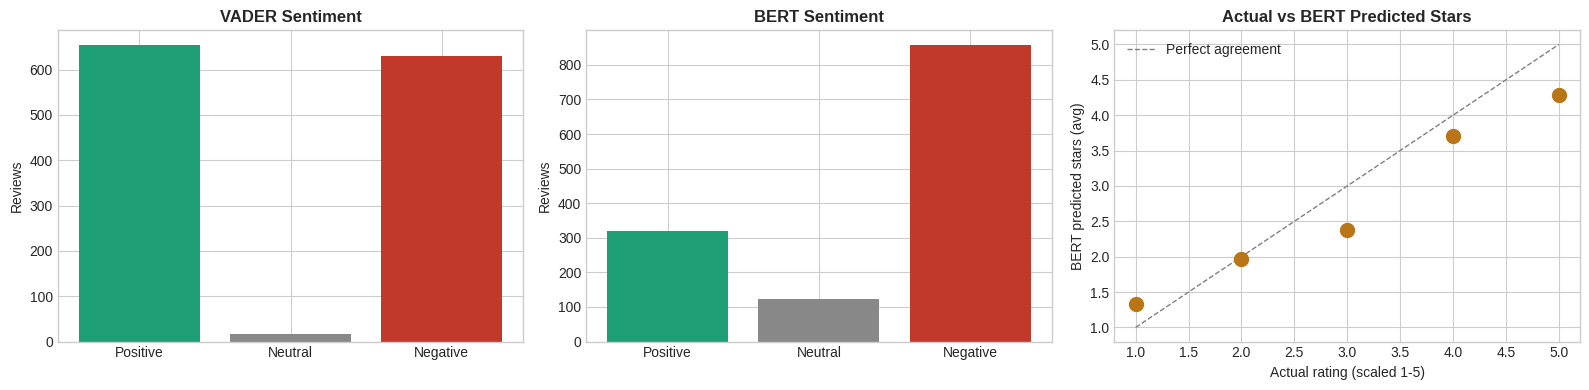

In [22]:
# Compare BERT predicted stars vs actual BA rating
# Scale BA rating (1-10) to match BERT (1-5) for comparison
df['ba_stars_scaled'] = (df['user_ratings'] / 2).round(0).astype(int).clip(1, 5)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# VADER vs BERT sentiment comparison
methods = [
    ('vader_sentiment', 'VADER Sentiment', '#534AB7'),
    ('bert_sentiment',  'BERT Sentiment',  '#1D9E75'),
]
for ax, (col, title, color) in zip(axes[:2], methods):
    counts = df[col].value_counts()
    order  = ['Positive','Neutral','Negative']
    cols   = {'Positive':'#1D9E75','Neutral':'#888888','Negative':'#C0392B'}
    ax.bar([o for o in order if o in counts.index],
           [counts.get(o, 0) for o in order if o in counts.index],
           color=[cols[o] for o in order if o in counts.index])
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Reviews')

# BERT predicted vs actual stars
star_compare = df.groupby('ba_stars_scaled')['bert_stars'].mean().reset_index()
axes[2].scatter(star_compare['ba_stars_scaled'], star_compare['bert_stars'],
                color='#BA7517', s=100, zorder=5)
axes[2].plot([1,5],[1,5], '--', color='grey', linewidth=1, label='Perfect agreement')
axes[2].set_title('Actual vs BERT Predicted Stars', fontweight='bold')
axes[2].set_xlabel('Actual rating (scaled 1-5)')
axes[2].set_ylabel('BERT predicted stars (avg)')
axes[2].legend()

plt.tight_layout()
plt.show()

In [23]:
# Find the most interesting cases: where BERT and the actual rating disagree
# High actual rating but BERT predicts negative = customer rates generously but text complains
# Low actual rating but BERT predicts positive = customer is a harsh rater

df['rating_sentiment_gap'] = df['ba_stars_scaled'] - df['bert_stars']

generous = df[(df['ba_stars_scaled'] >= 4) & (df['bert_sentiment'] == 'Negative')]
harsh = df[(df['ba_stars_scaled'] <= 2) & (df['bert_sentiment'] == 'Positive')]

print(f'Reviews where customer gave high rating but BERT reads as negative: {len(generous):,}')
print(f'Reviews where customer gave low rating but BERT reads as positive: {len(harsh):,}')

Reviews where customer gave high rating but BERT reads as negative: 47
Reviews where customer gave low rating but BERT reads as positive: 30


In [24]:
# Check the top generous raters and harsh raters
print('--- Reviews where customer gave high rating but BERT reads as negative ---')
print('(Generous raters who still complain in the text)')
for _, row in generous.nlargest(2, 'user_ratings').iterrows():
    print(f'\nActual: {row["user_ratings"]}/10 | BERT: {row["bert_stars"]} stars')
    print(row['reviews'])

print('\n--- Reviews where customer gave low rating but BERT reads as positive ---')
print('(Harsh raters whose text is actually quite balanced)')
for _, row in harsh.nsmallest(2, 'user_ratings').iterrows():
    print(f'\nActual: {row["user_ratings"]}/10 | BERT: {row["bert_stars"]} stars')
    print(row['reviews'])

--- Reviews where customer gave high rating but BERT reads as negative ---
(Generous raters who still complain in the text)

Actual: 10/10 | BERT: 2 stars
  A serious medical problem appeared while I was onboard. I informed the crew and they helped me out. Unfortunately I was in transit but travelling further became too difficult because of how unwell I became. Also I could not find my way back home in my condition. Thankfully the crew has helped me in every step of the journey until I returned back home. It was a stressful experience but the crew of British Airways made it way more tolerable.

Actual: 10/10 | BERT: 1 stars
  My husband and myself were flying to Madrid on the 3rd of February for a Legal matter and we had to be in Madrid by 13:00 pm. We had booked our flight and car with BA Holidays. Unfortunately we chose a parking we had never used before, we got lost, and missed our 6:00 am flight to Madrid. I tried to stay calm, cold head and we went to British Airways to get help. 

### What the sentiment analysis tells us

The rating-sentiment gap is the most commercially useful output — but the examples above show it requires careful interpretation. Not every gap between BERT prediction and actual rating represents a model error. Sometimes it reveals something genuinely interesting about how customers communicate.

**VADER vs BERT — why they disagree**

VADER counts positive and negative words. BERT understands context. The gap between them is largest for reviews that use polite language to describe bad experiences — common in British English. 'The flight was adequate' scores mildly positive in VADER because 'adequate' is not a negative word. BERT reads the full sentence in context and interprets it as a 2-star review — adequate is damning with faint praise. This is the core reason transformer-based models outperform rule-based approaches on nuanced review text.

**The rating vs text gap is commercially important**

Airlines and restaurants that measure satisfaction only through star ratings are missing the signal buried in the text. Customers who give 7/10 but write like a 3/10 are at-risk customers — they have not complained enough to show up in the ratings but their text reveals dissatisfaction. These are exactly the customers worth acting on before they churn, and they are invisible to any analysis that only looks at the star rating.

**Four types of disagreement — and what each means**

**Type 1 — Narrative reversal (high rating, negative BERT)**

The medical emergency review is a positive story about crew performance in a crisis. The model reads crisis language and scores it low. Sentiment models cannot reliably handle narratives where a bad situation leads to a positive outcome. The emotional language of the bad event dominates the signal regardless of the overall story arc.

**Type 2 — Late pivot (high rating, negative BERT)**

The Althea story spends most of its length on the complaint before pivoting to praise. The model reads the first 512 tokens — mostly complaint — and scores it accordingly. A review where the key sentiment appears in the final paragraph will always be at risk of misclassification due to truncation.

**Type 3 — Positive framing of a bad experience (low rating, positive BERT)**

The France holiday review opens with "special holiday", "Business Class", "lovely South of France" before the complaints begin. The model anchors on the opening tone. This is a common pattern in detailed complaint reviews — customers set a positive scene before describing what went wrong.

**Type 4 — Measured tone without emotional language (low rating, positive BERT)**

The seat separation review is factual and controlled — no exclamation marks, no strong negative words, just a calm description of a grievance. Both VADER and BERT struggle here because the negative signal is in the meaning of the situation, not in the words used. A highly articulate, measured complaint looks positive to a sentiment model.

**What this means for how you use sentiment analysis**

Sentiment models are reliable for aggregate patterns, not individual classifications. When you say "60% of reviews about delays are negative" — that finding is robust even with individual errors. When you say "this specific customer is unhappy" — you should always verify manually before acting on it.

**Three questions to ask before presenting sentiment findings to a client:**

1. **Is this a ranking or a classification task?** Ranking topics by % negative sentiment is reliable. Classifying individual reviews for customer outreach requires manual validation of a sample.

2. **Have you checked the disagreements?** The cases where model and rating diverge most are the most analytically interesting — sometimes they reveal model limitations, sometimes they reveal genuinely ambiguous reviews that no model would get right.
3. **Does the error pattern matter for your specific claim?** If the model systematically misreads narrative-structure reviews but your claim is about keyword-heavy complaints, the error pattern may not affect your conclusion. Understand where it fails before deciding whether it matters for your analysis.

**For your Yelp assignment:** run a manual check on 20 reviews where BERT prediction and Yelp rating diverge most. Categorise each disagreement using the four types above — is it a model error or a genuinely ambiguous review? This honest assessment demonstrates analytical maturity and is exactly what a client presentation should include.

---
## Part 2 — Topic Modelling with BERTopic

**Business question:** What themes are British Airways customers actually talking about?

**How BERTopic works — connecting to what you already know:**

```
Text reviews
      ↓
Sentence embeddings (all-MiniLM-L6-v2)
→ each review becomes a 384-dimensional vector capturing its meaning
      ↓
UMAP dimensionality reduction
→ reduces 384D to 5D so clustering can find meaningful groups
→ same concept as PCA but better for non-linear structure
      ↓
HDBSCAN clustering
→ groups semantically similar reviews together
→ unlike K-means: handles noise, does not force every review into a cluster
      ↓
c-TF-IDF topic representation
→ finds words most distinctive to each cluster vs all other clusters
      ↓
KeyBERTInspired refinement (best practice)
→ uses embeddings to improve keyword quality beyond simple frequency
      ↓
Topics + keywords + representative documents
```

**Why BERTopic over LDA for reviews:**
LDA uses word co-occurrence frequencies. BERTopic uses meaning. 'Waited ages' and 'queue was very long' end up in the same topic even though they share no words.

In [25]:
from bertopic import BERTopic
from bertopic.representation import KeyBERTInspired
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')

# Filter to reviews long enough for meaningful topics
df_bert = df[df['word_count'] >= 50].copy().reset_index(drop=True)
docs    = df_bert['reviews_clean'].tolist()

print(f'Reviews for BERTopic: {len(docs):,} (50+ words)')
print(f'Average length: {df_bert["word_count"].mean():.0f} words')

Reviews for BERTopic: 1,171 (50+ words)
Average length: 163 words


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [26]:
# Step 1: Compute embeddings
# We compute these separately so BERTopic can reuse them
# if you need to re-run with different parameters
# With T4 GPU: ~15 seconds. Without GPU: ~3 minutes.

print('Loading embedding model...')
embedding_model = SentenceTransformer('all-MiniLM-L6-v2',
                                       device=device)

print(f'Computing embeddings on {device}...')
embeddings = embedding_model.encode(
    docs,
    show_progress_bar=True,
    batch_size=64 if device == 'cuda' else 16
)
print(f'Embeddings shape: {embeddings.shape}')
print('Done. Embeddings saved — re-run BERTopic without recomputing.')

Loading embedding model...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Computing embeddings on cuda...


Batches:   0%|          | 0/19 [00:00<?, ?it/s]

Embeddings shape: (1171, 384)
Done. Embeddings saved — re-run BERTopic without recomputing.


In [27]:
# Step 2: Configure BERTopic components

# ── Scale min_cluster_size to dataset size ─────────────────────────────────
# Starting point — adjust based on your results
# Too many topics → increase; too few → decrease
n_docs = len(docs)
min_cluster_size = max(10, min(50, int(n_docs * 0.02)))
print(f'Documents: {n_docs:,}')
print(f'Recommended min_cluster_size: {min_cluster_size}')
print()

# ── UMAP: reduce dimensions before clustering ──────────────────────────────
umap_model = UMAP(
    n_neighbors=10,    # lower = more local structure = tighter clusters
    n_components=5,    # target dimensions (5 is BERTopic standard)
    min_dist=0.0,      # how tightly to pack similar points
    metric='cosine',
    random_state=42
)

# ── HDBSCAN: density-based clustering ─────────────────────────────────────
# We use the scaled min_cluster_size rather than a fixed number
# This ensures the model works consistently on different dataset sizes
hdbscan_model = HDBSCAN(
    min_cluster_size=min_cluster_size,
    min_samples=3,         # lower = less conservative, fewer noise points
    metric='euclidean',
    prediction_data=True
)

# ── CountVectorizer: controls keywords for c-TF-IDF ───────────────────────
# Stop words applied here only — NOT before embedding
# Removing domain-specific words that appear in every review
# prevents them dominating every topic's keywords
custom_stops = (
    list(stopwords.words('english')) +
    ['british', 'airways', 'airline', 'airlines', 'ba',
     'flight', 'flights', 'flew', 'fly']
)

vectorizer = CountVectorizer(
    stop_words=custom_stops,
    ngram_range=(1, 2),    # include 2-word phrases e.g. 'customer service'
    min_df=2               # word must appear in at least 2 reviews
)

# ── KeyBERTInspired: best practice representation refinement ───────────────
# Improves keyword quality using embeddings rather than just frequency
representation_model = KeyBERTInspired()

print('Components configured.')
print()
print('Note: after fitting, use reduce_topics() to control final topic count.')
print('Use visualize_hierarchy() to decide the right target number.')

Documents: 1,171
Recommended min_cluster_size: 23

Components configured.

Note: after fitting, use reduce_topics() to control final topic count.
Use visualize_hierarchy() to decide the right target number.


In [28]:
# Step 3: Build and run BERTopic
# With T4 GPU embeddings already computed: ~20 seconds
# Without GPU: ~2 minutes

print('Running BERTopic...')

topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer,
    representation_model=representation_model,
    calculate_probabilities=False,  # saves memory on free tier
    verbose=False
)

# Pass pre-computed embeddings — avoids recomputing
topics, _ = topic_model.fit_transform(docs, embeddings=embeddings)
df_bert['topic'] = topics

n_topics = len(set(topics)) - (1 if -1 in topics else 0)
print(f'Found {n_topics} topics')
print(f'Reviews assigned to a topic: {sum(t != -1 for t in topics):,}')
print(f'Unassigned (noise, topic -1): {sum(t == -1 for t in topics):,}')

Running BERTopic...
Found 16 topics
Reviews assigned to a topic: 800
Unassigned (noise, topic -1): 371


In [29]:
# ── Step 3b: Optimise topic count ─────────────────────────────────────────
# Check how many topics were found initially
n_initial = len(topic_model.get_topic_info()) - 1  # exclude noise topic -1
print(f'Initial topics found: {n_initial}')
print()

# Visualise hierarchy — use this to decide your reduction target
# Topics that branch close together are good candidates for merging
print('Generating topic hierarchy...')
topic_model.visualize_hierarchy()

Initial topics found: 16

Generating topic hierarchy...


In [30]:
# ── Step 3c: Reduce to interpretable number of topics ─────────────────────
# 'auto' merges topics below a similarity threshold — most consistent approach
# For a client presentation, 6-10 topics is usually the right range
# If 'auto' gives too many or too few, replace with a specific number e.g. nr_topics=8

topic_model.reduce_topics(docs, nr_topics=8)

# Update topic assignments in the DataFrame
df_bert['topic'] = topic_model.topics_

n_final = len(topic_model.get_topic_info()) - 1
print(f'Topics after reduction: {n_final}')

Topics after reduction: 7


In [31]:
# Explore topics
topic_info = topic_model.get_topic_info()
print('Topics found (excluding noise):')
topic_info

Topics found (excluding noise):


,Topic,Count,Name,Representation,Representative_Docs
0,-1,371,-1_boarding_passengers_cabin crew_airport,"[boarding, passengers, cabin crew, airport, cabin, heathrow, flying, departure, luggage, booked]",[Much better experience this time around. Flew CPT to LHR on a new A350. Checkin was efficient. I used the Bidvest l...
1,0,240,0_seating_boarding_seats_business class,"[seating, boarding, seats, business class, passengers, cabin crew, cabin, seat, lounge, heathrow]","[The check-in process was smooth. I got access to the IGA Lounge which was nice, but not as nice has the Turkish Air..."
2,1,207,1_refund_cancellation_cancel_booking,"[refund, cancellation, cancel, booking, customer service, ticket, heathrow, cancelled, return, flying]",[I booked flights to Rome from the US and then home through London to LAX in February of this year for the 1st of Au...
3,2,130,2_london heathrow_heathrow_qantas_london,"[london heathrow, heathrow, qantas, london, via london, boarding, cabin, aircraft, plane, flying]",[Sydney to London via Singapore. It has been a very long time since I was on a long haul with BA of more than 9 hour...
4,3,115,3_baggage_heathrow_london heathrow_luggage,"[baggage, heathrow, london heathrow, luggage, airport, dublin, bag, bags, boarding, arrive]","[Feb 25, 2022. We show up at the airport 3 hours early for our flight to Dublin. we waited in line for 3+ hours to j..."
5,4,57,4_gatwick_london gatwick_boarding_lounge,"[gatwick, london gatwick, boarding, lounge, seats, airport, london, club europe, drinks, passengers]",[Gatwick to Malaga. Check in was fairly quick. The check in area at Gatwick is quite nice although they are failing ...
6,5,28,5_passengers_cabin crew_great service_heathrow,"[passengers, cabin crew, great service, heathrow, london heathrow, boarding, courtesy, arrived, traveling, cabin]","[Seattle to Durban via London. On 24th of July i arrived late just before departure time 1330hrs, the shuttle bus pi..."
7,6,23,6_meal service_meal_meals_boarding,"[meal service, meal, meals, boarding, attendant, dinner, passengers, served, drinks, crew]","[Barbados to Gatwick. We boarded a half full flight and whilst preparing for take off the video was shown as normal,..."


Topic -1 contains all documents that couldn't be confidently assigned to any specific cluster. Having
reviews classified as outliers suggests a few possibilities:

- High diversity in your reviews: the reviews might cover many different topics with little overlap, making it difficult for the algorithm to find clear clusters.

- Noise in the data: If the reviews are short or contain unusual language patterns, they might be harder to cluster effectively.

In [32]:
# Print topic keywords clearly
print('Top keywords per topic:\n')
for _, row in topic_info[topic_info['Topic'] != -1].iterrows():
    topic_id = row['Topic']
    keywords = topic_model.get_topic(topic_id)
    words    = ' · '.join([w[0] for w in keywords[:8]])
    print(f'Topic {topic_id:2d} ({row["Count"]:3d} reviews): {words}')

Top keywords per topic:

Topic  0 (240 reviews): seating · boarding · seats · business class · passengers · cabin crew · cabin · seat
Topic  1 (207 reviews): refund · cancellation · cancel · booking · customer service · ticket · heathrow · cancelled
Topic  2 (130 reviews): london heathrow · heathrow · qantas · london · via london · boarding · cabin · aircraft
Topic  3 (115 reviews): baggage · heathrow · london heathrow · luggage · airport · dublin · bag · bags
Topic  4 ( 57 reviews): gatwick · london gatwick · boarding · lounge · seats · airport · london · club europe
Topic  5 ( 28 reviews): passengers · cabin crew · great service · heathrow · london heathrow · boarding · courtesy · arrived
Topic  6 ( 23 reviews): meal service · meal · meals · boarding · attendant · dinner · passengers · served


In [33]:
# Interactive visualisations
# Hover over topics to explore
topic_model.visualize_topics()

In [34]:
# Topic keyword bar charts
topic_model.visualize_barchart(n_words=10, height=400)

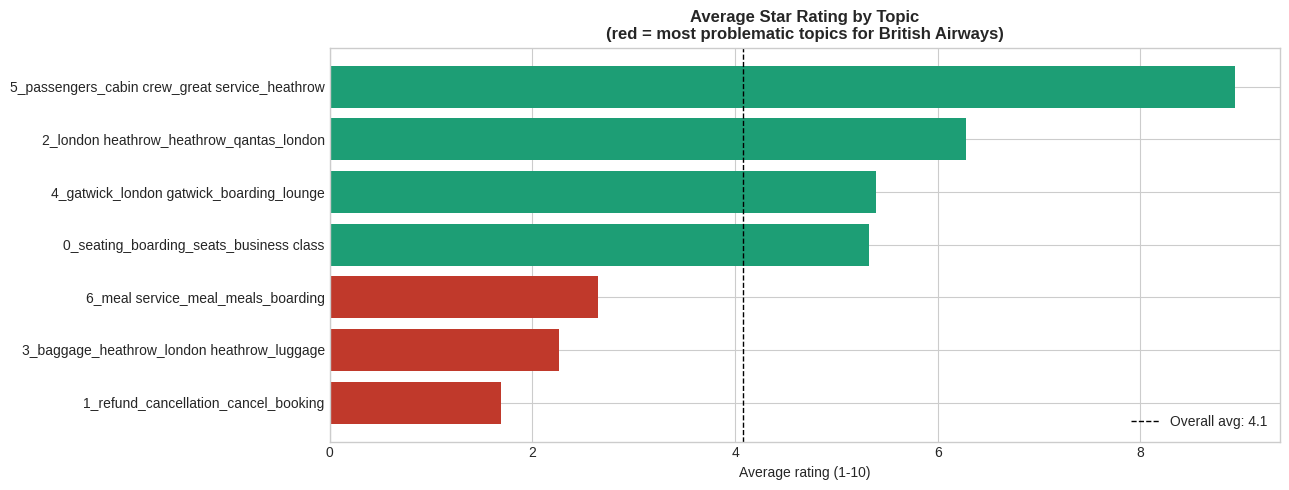

Topic performance table:


,label,count,avg_rating,pct_recommend,avg_bert_stars
1,1_refund_cancellation_cancel_booking,207,1.69,4.35,1.30
3,3_baggage_heathrow_london heathrow_luggage,115,2.26,11.30,1.41
6,6_meal service_meal_meals_boarding,23,2.65,8.70,2.09
0,0_seating_boarding_seats_business class,240,5.32,47.92,2.72
4,4_gatwick_london gatwick_boarding_lounge,57,5.39,49.12,2.77
2,2_london heathrow_heathrow_qantas_london,130,6.28,58.46,3.12
5,5_passengers_cabin crew_great service_heathrow,28,8.93,89.29,3.50


In [35]:
# Which topics are associated with the lowest ratings?
# This is the most actionable output for a business
topic_names = topic_info.set_index('Topic')['Name'].to_dict()

topic_perf = (
    df_bert[df_bert['topic'] != -1]
    .groupby('topic')
    .agg(
        count          = ('reviews',      'count'),
        avg_rating     = ('user_ratings',  'mean'),
        pct_recommend  = ('would_recommed_to_others',
                          lambda x: x.mean() * 100),
        avg_bert_stars = ('bert_stars',   'mean')
    )
    .round(2)
    .reset_index()
    .sort_values('avg_rating')
)
topic_perf['label'] = topic_perf['topic'].map(topic_names)

fig, ax = plt.subplots(figsize=(13, 5))
colors = ['#C0392B' if r < 3 else '#BA7517' if r < 5 else '#1D9E75'
          for r in topic_perf['avg_rating']]
ax.barh(topic_perf['label'], topic_perf['avg_rating'], color=colors)
ax.axvline(df_bert['user_ratings'].mean(), color='black', linestyle='--',
           linewidth=1, label=f'Overall avg: {df_bert["user_ratings"].mean():.1f}')
ax.set_title('Average Star Rating by Topic\n'
             '(red = most problematic topics for British Airways)',
             fontweight='bold')
ax.set_xlabel('Average rating (1-10)')
ax.legend()
plt.tight_layout()
plt.show()

print('Topic performance table:')
topic_perf[['label','count','avg_rating','pct_recommend','avg_bert_stars']]

In [36]:
# Show representative reviews for the lowest-rated topic
worst_topic = topic_perf.iloc[0]['topic']
worst_label = topic_perf.iloc[0]['label']

print(f'Most problematic topic: {worst_label}')
print(f'Average rating: {topic_perf.iloc[0]["avg_rating"]:.1f}/10')
print()

worst_reviews = df_bert[
    df_bert['topic'] == worst_topic
].nsmallest(3, 'user_ratings')

for i, (_, row) in enumerate(worst_reviews.iterrows(), 1):
    print(f'--- Review {i} (rating: {row["user_ratings"]}/10) ---')
    print(row['reviews'][:400])
    print()

Most problematic topic: 1_refund_cancellation_cancel_booking
Average rating: 1.7/10

--- Review 1 (rating: 1/10) ---
 Worst service ever. Lost baggage because of delayed flight and missed connection and no one is helping to get it back. British Airways website is broken so it doesn’t let me fill missing report and doesn’t give me missing file report number and so no way to contact British Airways because they have dumbest ever AI chatbot.

--- Review 2 (rating: 1/10) ---
  I just want to warn everyone of the worst customer service experience ever! It really looks like British Airways customer service over the phone are trained to not help you in anyway and to create more problems rather than solving them. Last week we called British Airways to make a reservation for the family. At the time we explained to the customer service representative that we wanted to make 

--- Review 3 (rating: 1/10) ---
 Paid for business class travelling Cairo to London Heathrow but all I got was an economy 

### Interpreting BERTopic output

Let's look at the specific outputs from our analysis:

**Topic -1 (noise):** This topic, comprising `341` reviews, represents documents that did not fit clearly into any distinct cluster. These are often either very generic reviews or highly specific, unique complaints that don't share enough semantic similarity with other reviews to form a coherent topic. It's always worth reviewing a sample of these to understand why they are outliers.

**c-TF-IDF keywords:** The keywords shown for each topic are not just the most frequent words, but rather those most *distinctive* to that topic. For example, for **Topic 0 (seating)**, keywords like 'seating', 'seats', and 'business class' are highlighted because they appear frequently in reviews about this topic but less so in other topics. Common words like 'flight' or 'customer' might appear in many reviews across all topics, so BERTopic de-emphasizes them, rewarding words that truly differentiate one topic from another.

**Combining with BERT sentiment:** This is where the real power lies. Our `topic_perf` table clearly shows how topics align with customer sentiment. For instance, **Topic 1 (refund, cancellation)** has an exceptionally low average user rating of `1.67/10` and an average BERT star rating of `1.33`. Similarly, **Topic 3 (baggage claim)** and **Topic 5 (delayed hours)** also show very low ratings and BERT sentiment. This strong convergence between the discovered topics and negative sentiment from an independent model confirms these are indeed problematic areas for British Airways. Conversely, **Topic 6 (cabin crew, great service)** stands out with an `8.93/10` average user rating and `3.48` BERT stars, indicating a strong positive area. This convergence makes findings highly credible and actionable for a client.

**Actionable Insights:** The topic-by-rating chart directly highlights operational issues that are driving the most dissatisfaction (e.g., 'refund/cancellation', 'baggage claim', 'delayed hours'). By drilling into representative reviews for these low-rated topics, such as the examples shown for the 'refund/cancellation' topic, we gain specific insights into the customer experience, enabling targeted improvements.

**For your Yelp project:** You can apply the same methodology. Replace `docs` with your restaurant reviews. BERTopic will naturally surface topics like 'waiting time', 'food quality', 'parking', or 'staff attitude'. The topic-by-rating chart will then directly inform which operational aspects of a restaurant are most loved or hated by customers.

---
## Part 3 — Short-form Text: Review Titles

**Business question:** What can very short text tell us — and why does BERTopic not work here?

Review titles average just 5-6 words. Too short for BERTopic — there is not enough semantic content per document for the embeddings to be distinctive enough for clustering.

Two techniques that work well on short text:

**KeyBERT** — extracts the most representative keywords from each text using BERT embeddings. Works on one document at a time — no clustering needed.

**Zero-shot classification** — classifies text into predefined categories without any training data. You define the categories based on your business question. Uses `facebook/bart-large-mnli` — trained on natural language inference.

### 3.1 — KeyBERT

KeyBERT is a keyword extraction technique that leverages BERT embeddings to find keywords and keyphrases in documents. Unlike traditional keyword extraction methods that rely on statistical measures (like TF-IDF) or rule-based approaches, KeyBERT uses the semantic understanding of a pre-trained transformer model like BERT.

**How it works:**
1.  **Embeddings:** The document (or in our case, a review title) is first embedded into a numerical vector space using a pre-trained Sentence Transformer model (like `all-MiniLM-L6-v2`). Each word or phrase in the document also gets its own embedding.
2.  **Similarity Calculation:** KeyBERT then calculates the cosine similarity between the document embedding and the embeddings of all candidate keywords/keyphrases within that document.
3.  **Max Sum Similarity:** To ensure diversity and relevance, KeyBERT often uses a "Max Sum Similarity" approach. This means it tries to find a set of keywords that are not only similar to the document but also dissimilar to each other, preventing the selection of redundant keywords.
4.  **Keyword Selection:** The keywords with the highest similarity scores to the document (and often, a good diversity score) are chosen as the most representative keyphrases.

**Why it's good for short texts:**
*   **Semantic Understanding:** Since it relies on BERT's contextual embeddings, it can understand the meaning of words and phrases even in short contexts, making it effective where statistical methods might fail due to lack of word frequency.
*   **No Training Needed:** KeyBERT doesn't require specific training data to extract keywords; it uses the general language understanding from its pre-trained model.
*   **Flexibility:** You can specify the `ngram_range` to extract single words, bigrams (two-word phrases), or even longer keyphrases, allowing you to tailor the output to your needs.

In [37]:
from keybert import KeyBERT

# Initialise KeyBERT model using the previously loaded SentenceTransformer embedding model.
# This saves memory and time by reusing the existing model rather than downloading a new one.
kw_model = KeyBERT(model=embedding_model)

# Print a header for the output.
print('KeyBERT keyword extraction from review titles:\n')

# Get the first 10 non-null titles from the DataFrame and convert them to a list.
# These will be used for a demonstration of keyword extraction.
sample_titles = df['title'].dropna().head(10).tolist()

# Iterate through each sample title.
for title in sample_titles:
    # Skip titles that have fewer than 3 words, as they are often too short for meaningful keyword extraction.
    if len(str(title).split()) < 3: continue

    # Extract keywords from the current title using KeyBERT.
    # `keyphrase_ngram_range=(1, 2)` allows for single words and two-word phrases.
    # `stop_words='english'` removes common English words before extraction.
    # `top_n=2` retrieves the top 2 most relevant keywords/keyphrases.
    kws = kw_model.extract_keywords(
        str(title),
        keyphrase_ngram_range=(1, 2),
        stop_words='english',
        top_n=2
    )

    # Print the original title.
    print(f'  Title: "{title}"')
    # Print the extracted keywords along with their relevance scores, rounded to two decimal places.
    print(f'  Keywords: {[(k, round(s,2)) for k,s in kws]}')
    print()

KeyBERT keyword extraction from review titles:

  Title: "Worst service ever"
  Keywords: [('worst service', 0.95), ('service', 0.67)]

  Title: "unprofessional attitude of the pilots"
  Keywords: [('unprofessional attitude', 0.7), ('attitude pilots', 0.63)]

  Title: "Next time it will be Jet2"
  Keywords: [('jet2', 0.83), ('time jet2', 0.73)]

  Title: "become the Ryanair of long-haul travel"
  Keywords: [('ryanair long', 0.76), ('ryanair', 0.74)]

  Title: "They never help us"
  Keywords: [('help', 0.21)]

  Title: "uncomfortable seat and disgusting food"
  Keywords: [('seat disgusting', 0.78), ('uncomfortable seat', 0.77)]

  Title: "Zero customer service"
  Keywords: [('zero customer', 0.9), ('customer service', 0.66)]

  Title: "baggage arrival nearly took 1.5 hours"
  Keywords: [('baggage arrival', 0.74), ('baggage', 0.49)]

  Title: "Overall very satisfied"
  Keywords: [('overall satisfied', 0.96), ('satisfied', 0.74)]

  Title: "airline is a total disgrace"
  Keywords: [('airl

Extracting keywords from 1,266 titles...


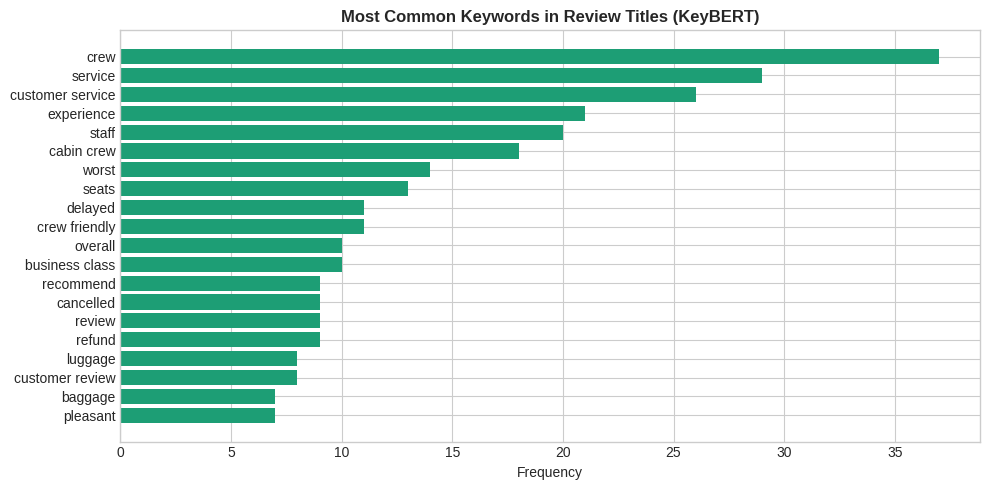

In [38]:
# Aggregate across all titles — what do customers mention most?
from collections import Counter
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True)

all_keywords = []
valid_titles = df['title'].dropna()
valid_titles = valid_titles[valid_titles.str.split().str.len() >= 3]

# Define custom stopwords to remove common, less informative words for this dataset
custom_stopwords = list(stopwords.words('english')) + \
                   ['british', 'airways', 'airline', 'ba', 'flight','fly','flew']

print(f'Extracting keywords from {len(valid_titles):,} titles...')
for title in valid_titles:
    kws = kw_model.extract_keywords(
        str(title),
        keyphrase_ngram_range=(1, 2),
        stop_words=custom_stopwords, # Use the extended stop words
        top_n=2
    )
    all_keywords.extend([k for k, s in kws if s > 0.25])

kw_counts = Counter(all_keywords).most_common(20)

# Visualise
fig, ax = plt.subplots(figsize=(10, 5))
words  = [k for k, _ in kw_counts]
counts = [c for _, c in kw_counts]
ax.barh(words[::-1], counts[::-1], color='#1D9E75')
ax.set_title('Most Common Keywords in Review Titles (KeyBERT)', fontweight='bold')
ax.set_xlabel('Frequency')
plt.tight_layout()
plt.show()

### 3.2 — Zero-shot classification

Zero-shot classification is a powerful NLP technique that allows you to classify text into categories without needing to train a model specifically on those categories. It leverages a pre-trained language model, like `facebook/bart-large-mnli`, which has been trained on a vast amount of text data to understand semantic relationships.

The `facebook/bart-large-mnli` model is particularly well-suited for this task because it's trained on Natural Language Inference (NLI) tasks. In NLI, the model learns to determine the relationship between two sentences (e.g., entailment, contradiction, or neutrality). This ability to understand semantic relationships allows it to infer whether a given text belongs to a specific category, even if it has never seen examples of that category during training.

**How it works:**
1.  You provide the text you want to classify (e.g., a review title).
2.  You provide a list of candidate labels (categories, e.g., 'customer service', 'flight delay').
3.  The model frames the classification as an NLI problem: "The review title is about [category]." It then determines how strongly the original text entails this hypothesis for each category.
4.  The category with the highest entailment score is chosen as the predicted label, along with a confidence score.

This approach is highly flexible, allowing you to define custom categories based on your business needs without the time-consuming process of collecting and labeling training data for each new classification task.

In [39]:
from transformers import pipeline as hf_pipeline

# facebook/bart-large-mnli — trained on natural language inference
# No training data needed — you define the categories
# This is powerful: categories are driven by your business question,
# not by what the training data happened to include

print('Loading zero-shot model (facebook/bart-large-mnli)...')
zs_pipe = hf_pipeline(
    'zero-shot-classification',
    model='facebook/bart-large-mnli',
    device=0 if device == 'cuda' else -1
)
print('Model ready.')

Loading zero-shot model (facebook/bart-large-mnli)...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Model ready.


In [40]:
# Define categories relevant to an airline
# For other dataset, you might need to think about what might be appropriate categories based on your understanding of the business context

categories = [
    'customer service and staff',
    'flight delay or cancellation',
    'seat comfort and cabin',
    'food and drink',
    'baggage handling',
    'value for money',
    'check-in and boarding',
]

# Run on all valid titles
print(f'Classifying {len(valid_titles):,} titles...')
print('With T4 GPU: ~30 seconds. Without GPU: ~3 minutes.')

zs_results = zs_pipe(
    valid_titles.tolist(),
    categories,
    multi_label=False,
    batch_size=16 if device == 'cuda' else 4
)

df_titles = pd.DataFrame({
    'title':      valid_titles.values,
    'category':   [r['labels'][0] for r in zs_results],
    'confidence': [round(r['scores'][0], 3) for r in zs_results]
})

print('Done.')
print()
print('Category distribution:')
print(df_titles['category'].value_counts())

Classifying 1,266 titles...
With T4 GPU: ~30 seconds. Without GPU: ~3 minutes.
Done.

Category distribution:
category
value for money                 391
customer service and staff      277
flight delay or cancellation    230
seat comfort and cabin          207
baggage handling                 82
food and drink                   58
check-in and boarding            21
Name: count, dtype: int64


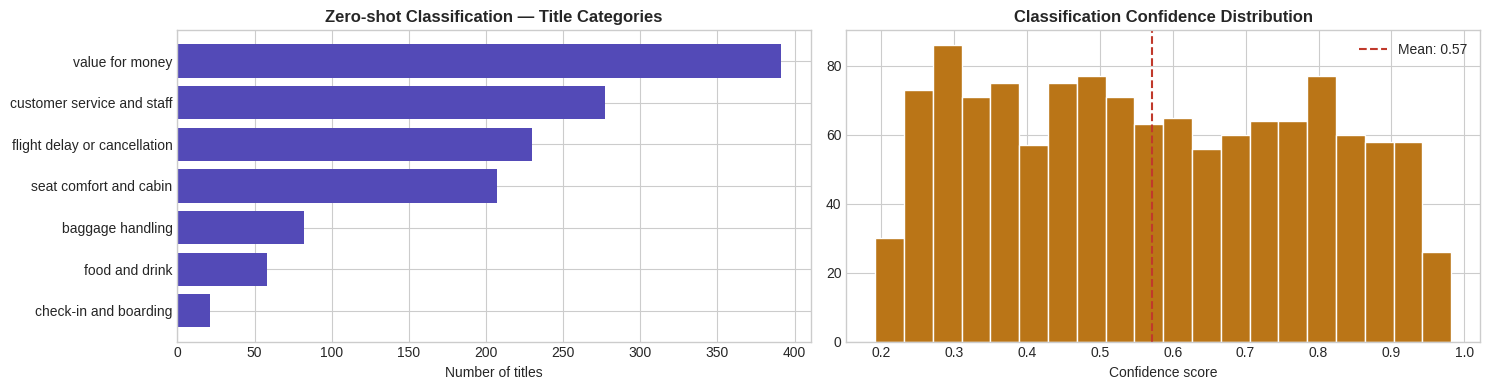

Sample classifications:


,title,category,confidence
422,Overall a very pleasant trip,value for money,0.918
1118,the food is really poor,food and drink,0.860
848,no apologies from the staff,customer service and staff,0.855
781,Abysmal customer services,customer service and staff,0.843
43,Customer Service is non existent,customer service and staff,0.716
23,Does BA pay experts to design these breakfasts,food and drink,0.645
1210,75 minutes to get boarding card,check-in and boarding,0.527
581,British Airways customer review,customer service and staff,0.465
1039,I felt like a nuisance,flight delay or cancellation,0.250
405,they should be ashamed,customer service and staff,0.238


In [41]:
# Visualise zero-shot results
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# Category counts
cat_counts = df_titles['category'].value_counts()
axes[0].barh(cat_counts.index[::-1], cat_counts.values[::-1], color='#534AB7')
axes[0].set_title('Zero-shot Classification — Title Categories', fontweight='bold')
axes[0].set_xlabel('Number of titles')

# Confidence distribution
axes[1].hist(df_titles['confidence'], bins=20, color='#BA7517', edgecolor='white')
axes[1].axvline(df_titles['confidence'].mean(), color='#C0392B', linestyle='--',
                label=f'Mean: {df_titles["confidence"].mean():.2f}')
axes[1].set_title('Classification Confidence Distribution', fontweight='bold')
axes[1].set_xlabel('Confidence score')
axes[1].legend()

plt.tight_layout()
plt.show()

# Show sample classifications
print('Sample classifications:')
df_titles.sample(10, random_state=42).sort_values('confidence', ascending=False)

### Short-form text takeaways

**Why KeyBERT works on short text:** it does not need to cluster documents. It just finds the words in a single document that are most semantically central to that document's meaning. Five words is enough for this.

**Why zero-shot is powerful:** you define the categories. For a restaurant client you would define entirely different categories than for an airline — the model does not need to be retrained. This is how enterprise NLP tools work: one large pre-trained model, customised by the analyst's category definitions.

**Watch the confidence scores:** classifications below 0.5 confidence are unreliable. Filter these out before presenting results to a client. Low confidence often means the text is ambiguous or genuinely spans multiple categories.

---
## Part 4 — Synthesis

### Which technique for which question?

| Technique | Use when | Output | Limitation |
|---|---|---|---|
| **VADER** | Quick baseline, large volume, no GPU | Positive/Negative/Neutral | Misses context, sarcasm, negation |
| **BERT sentiment** | Accurate rating prediction from text | 1-5 star prediction + confidence | Needs GPU for speed at scale |
| **BERTopic** | Discovering unknown themes in long text (50+ words) | Topic clusters + keywords | Too short text degrades quality |
| **KeyBERT** | Keyword extraction from any length text | Keywords + relevance scores | Does not group or categorise |
| **Zero-shot** | Categorising text into predefined labels | Category + confidence | Categories must be defined upfront; low confidence = unreliable |

### Recommended pipeline for your Yelp group project

```python
# Long-form: Yelp reviews
BERTopic(reviews)        → What themes appear? Which have lowest ratings?
BERT sentiment(reviews)  → Are customers positive? Where does text diverge from stars?

# Short-form: Yelp tips
KeyBERT(tips)            → What words appear most in tips?
Zero-shot(tips)          → Which operational category does each tip address?
                           You need to define the category
```